# Telecom Churn Prediction – Random Forest Baseline

Goals:
- Load the preprocessed dataset.
- Split the data into training and testing sets.
- Train a Random Forest classifier as a baseline model.
- Evaluate model performance using classification metrics.
- Analyze feature importance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import joblib
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../../data/processed/telecom_churn_clean.csv")

df.head()

,tenure,MonthlyCharges,Churn,num_services,gender_Male,Dependents_Yes,PhoneService_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,charge_level_medium,charge_level_high,tenure_group_early,tenure_group_established,tenure_group_loyal
0,-1.277445,-1.160323,0,-0.561776,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
1,0.066327,-0.259629,0,-0.020519,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False
2,-1.236724,-0.362660,1,-0.020519,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False
3,0.514251,-0.746535,0,0.520738,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False
4,-1.236724,0.197365,1,-1.103033,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,False


In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (7043, 20)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   tenure                                 7043 non-null   float64
 1   MonthlyCharges                         7043 non-null   float64
 2   Churn                                  7043 non-null   int64  
 3   num_services                           7043 non-null   float64
 4   gender_Male                            7043 non-null   bool   
 5   Dependents_Yes                         7043 non-null   bool   
 6   PhoneService_Yes                       7043 non-null   bool   
 7   InternetService_Fiber optic            7043 non-null   bool   
 8   InternetService_No                     7043 non-null   bool   
 9   Contract_One year                      7043 non-null   bool   
 10  Contract_Two year                      7043 non-null   bool   
 11  Pape

In [5]:
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 19)
Test size: (1409, 19)


In [7]:
rf_model = RandomForestClassifier(random_state=42,class_weight="balanced") #class_weight="balanced" handle class imbalance..

# Hyperparameter grid
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Randomized Search
rf_random = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=25,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)

# Best model
best_rf_model = rf_random.best_estimator_

print("Best Parameters:", rf_random.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}


In [8]:
y_pred_test = best_rf_model.predict(X_test)
y_prob_test = best_rf_model.predict_proba(X_test)[:, 1]

y_pred_train=best_rf_model.predict(X_train)
y_prob_train=best_rf_model.predict_proba(X_train)[:, 1]

# Model Evaluation

In [9]:
#Accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)
train_accuracy = accuracy_score(y_train, y_pred_train)

print("Test Accuracy:", test_accuracy)
print("Train Accuracy:", train_accuracy)

Test Accuracy: 0.7601135557132718
Train Accuracy: 0.8123890663826766


In [10]:
#Classification Report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



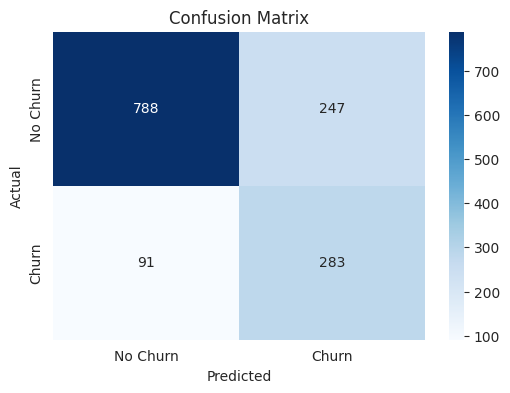

In [11]:
#ROC-AUC Score
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

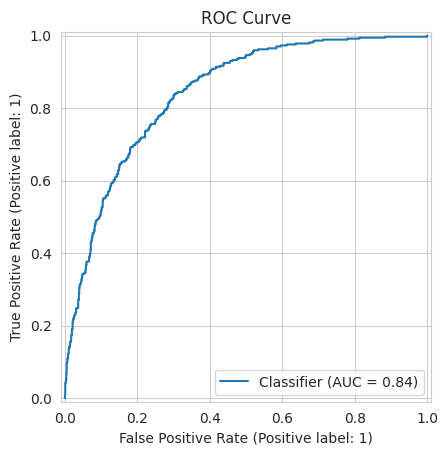

In [12]:
#ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_test)

plt.title("ROC Curve")
plt.show()

In [13]:
#Feature Importance
importances = best_rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
0,tenure,0.229405
1,MonthlyCharges,0.137556
9,Contract_Two year,0.131415
6,InternetService_Fiber optic,0.103468
12,PaymentMethod_Electronic check,0.068774
8,Contract_One year,0.058188
18,tenure_group_loyal,0.050503
2,num_services,0.041617
7,InternetService_No,0.041142
10,PaperlessBilling_Yes,0.027357


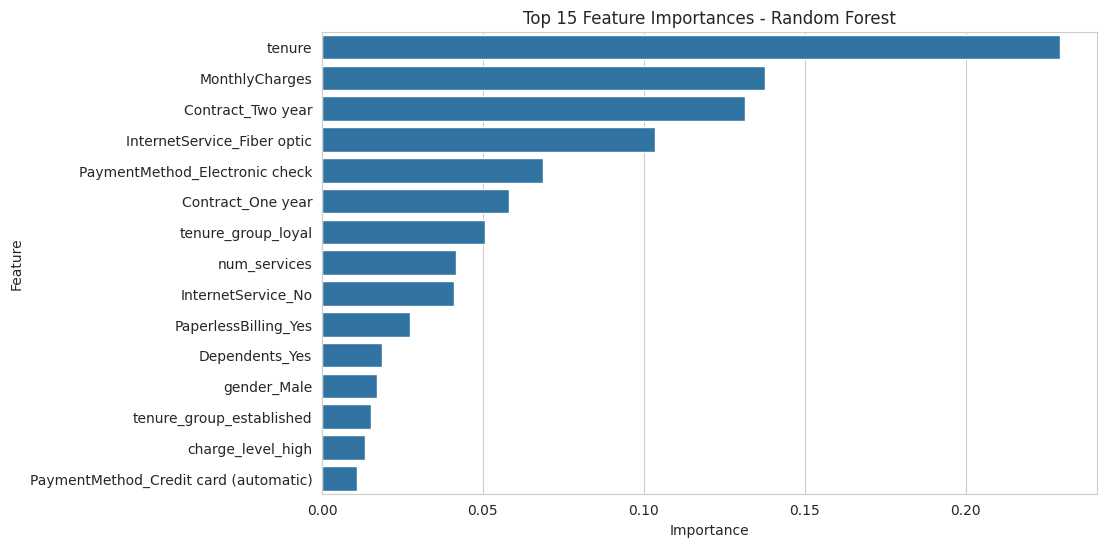

In [14]:
#plot feature importance
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="importance",
    y="feature",
    data=top_features
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [15]:
joblib.dump(best_rf_model, "../models/random_forest_baseline.pkl")

['../models/random_forest_baseline.pkl']